In [1]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-03/"
slurm_job = 16144791

result_dir = result_dir + date + str(slurm_job) + "/"
# result_dir = result_dir + date + "v/"

In [2]:
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    raise ValueError(f"File {filename} has fewer than {i} lines")

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_79097/3444692338.py:94: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


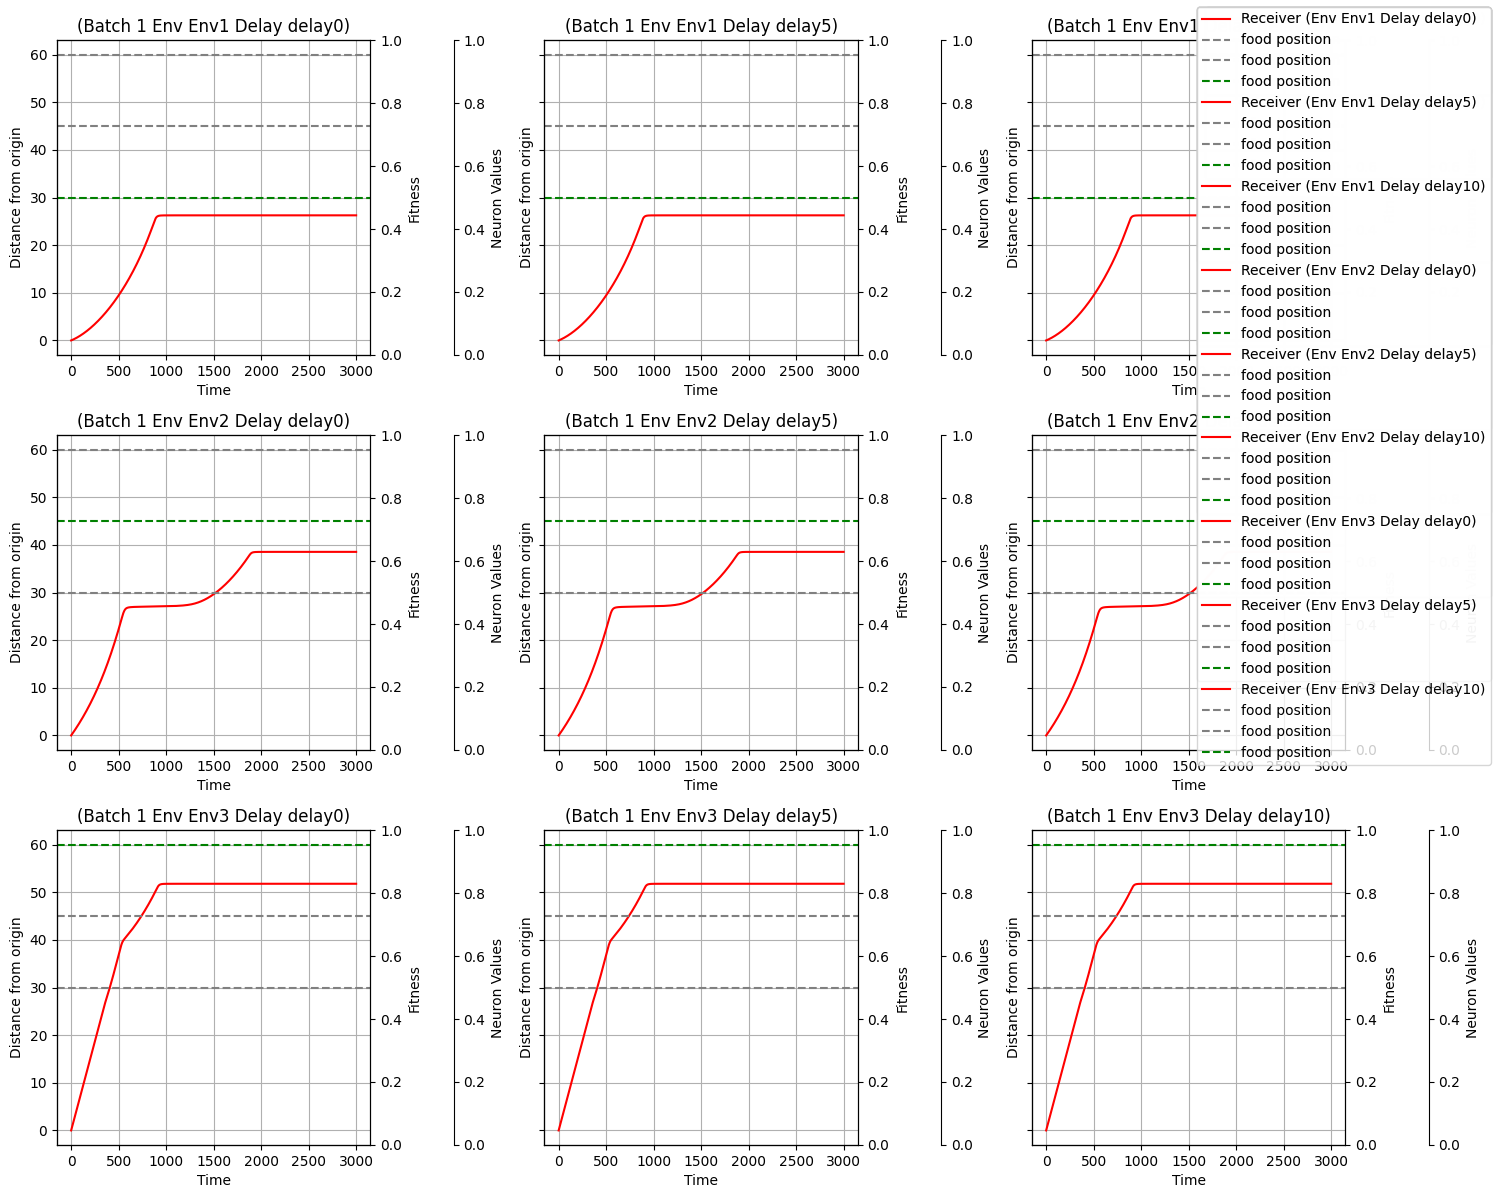

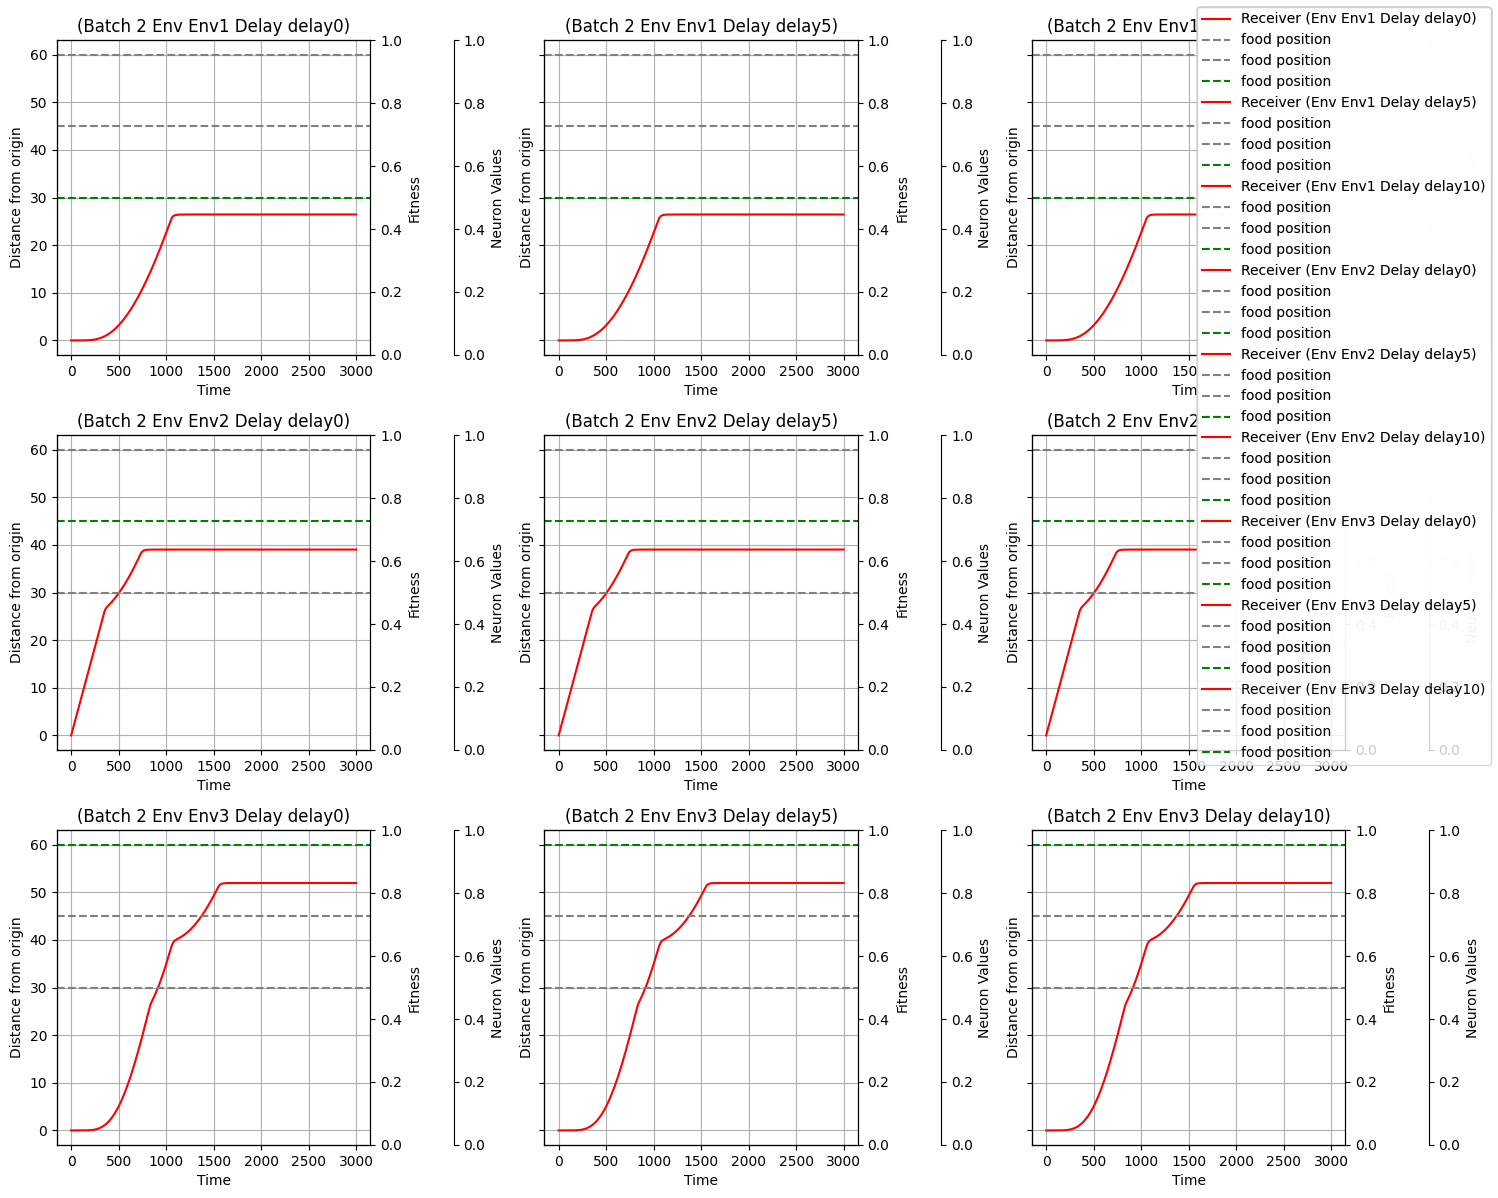

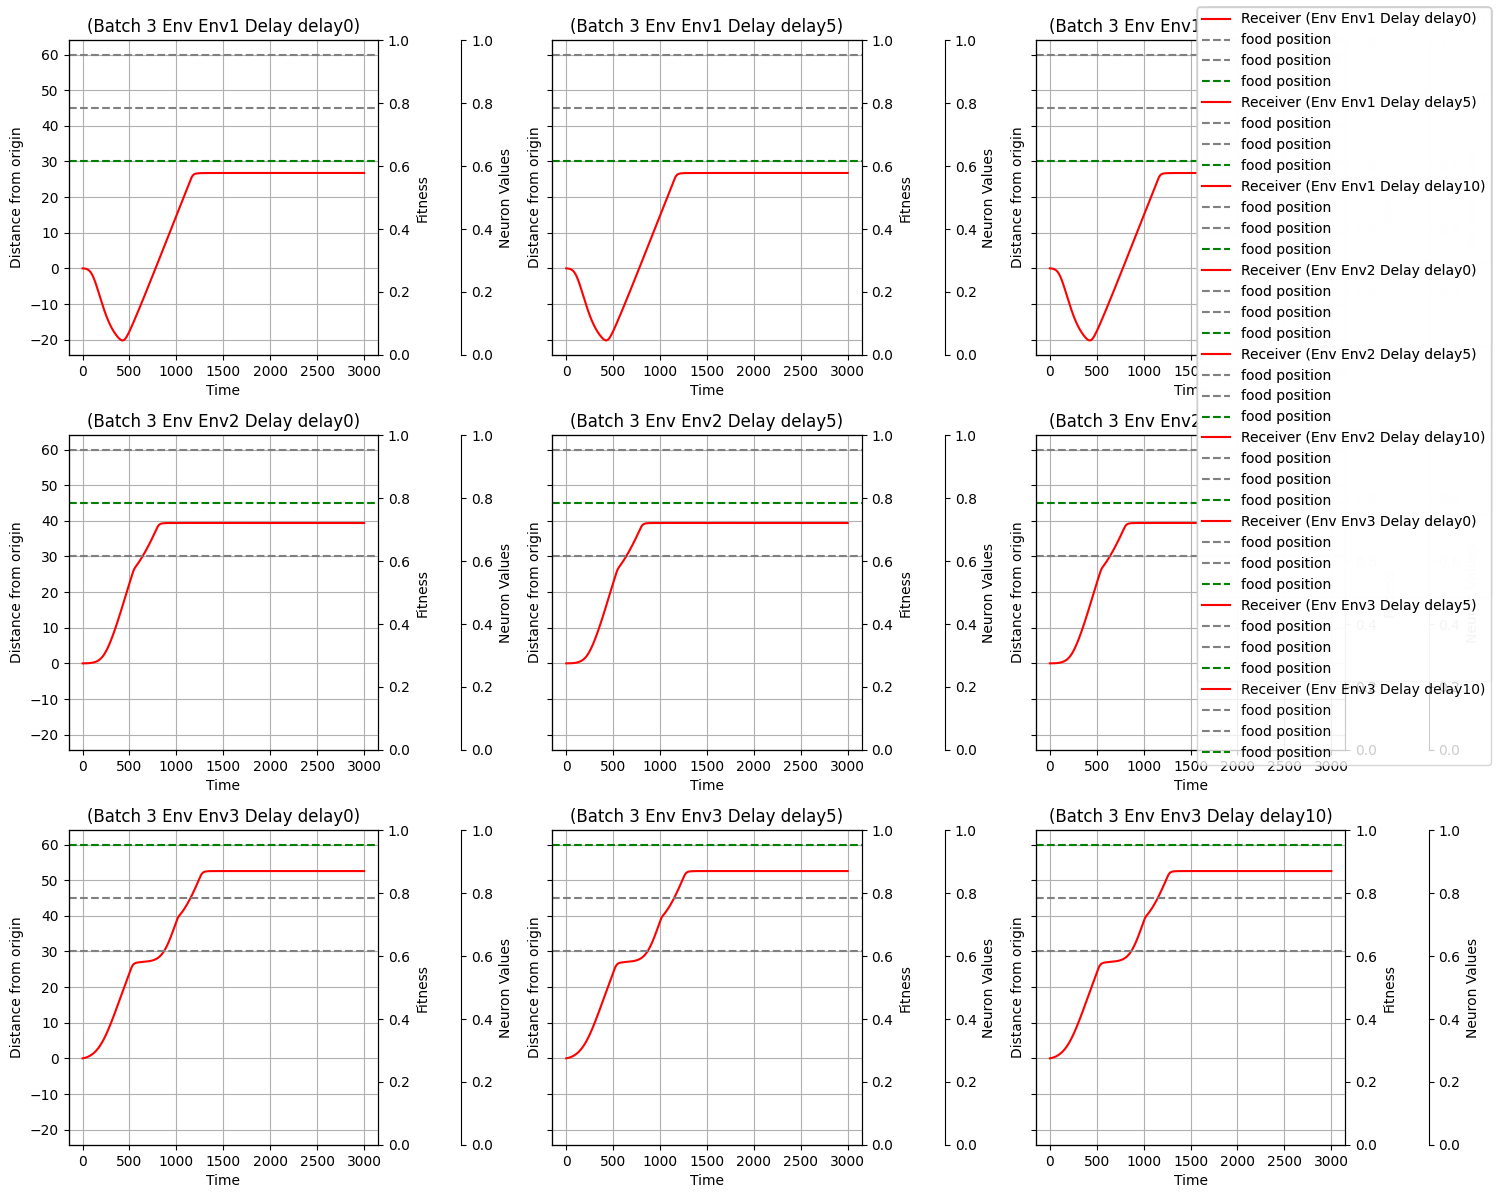

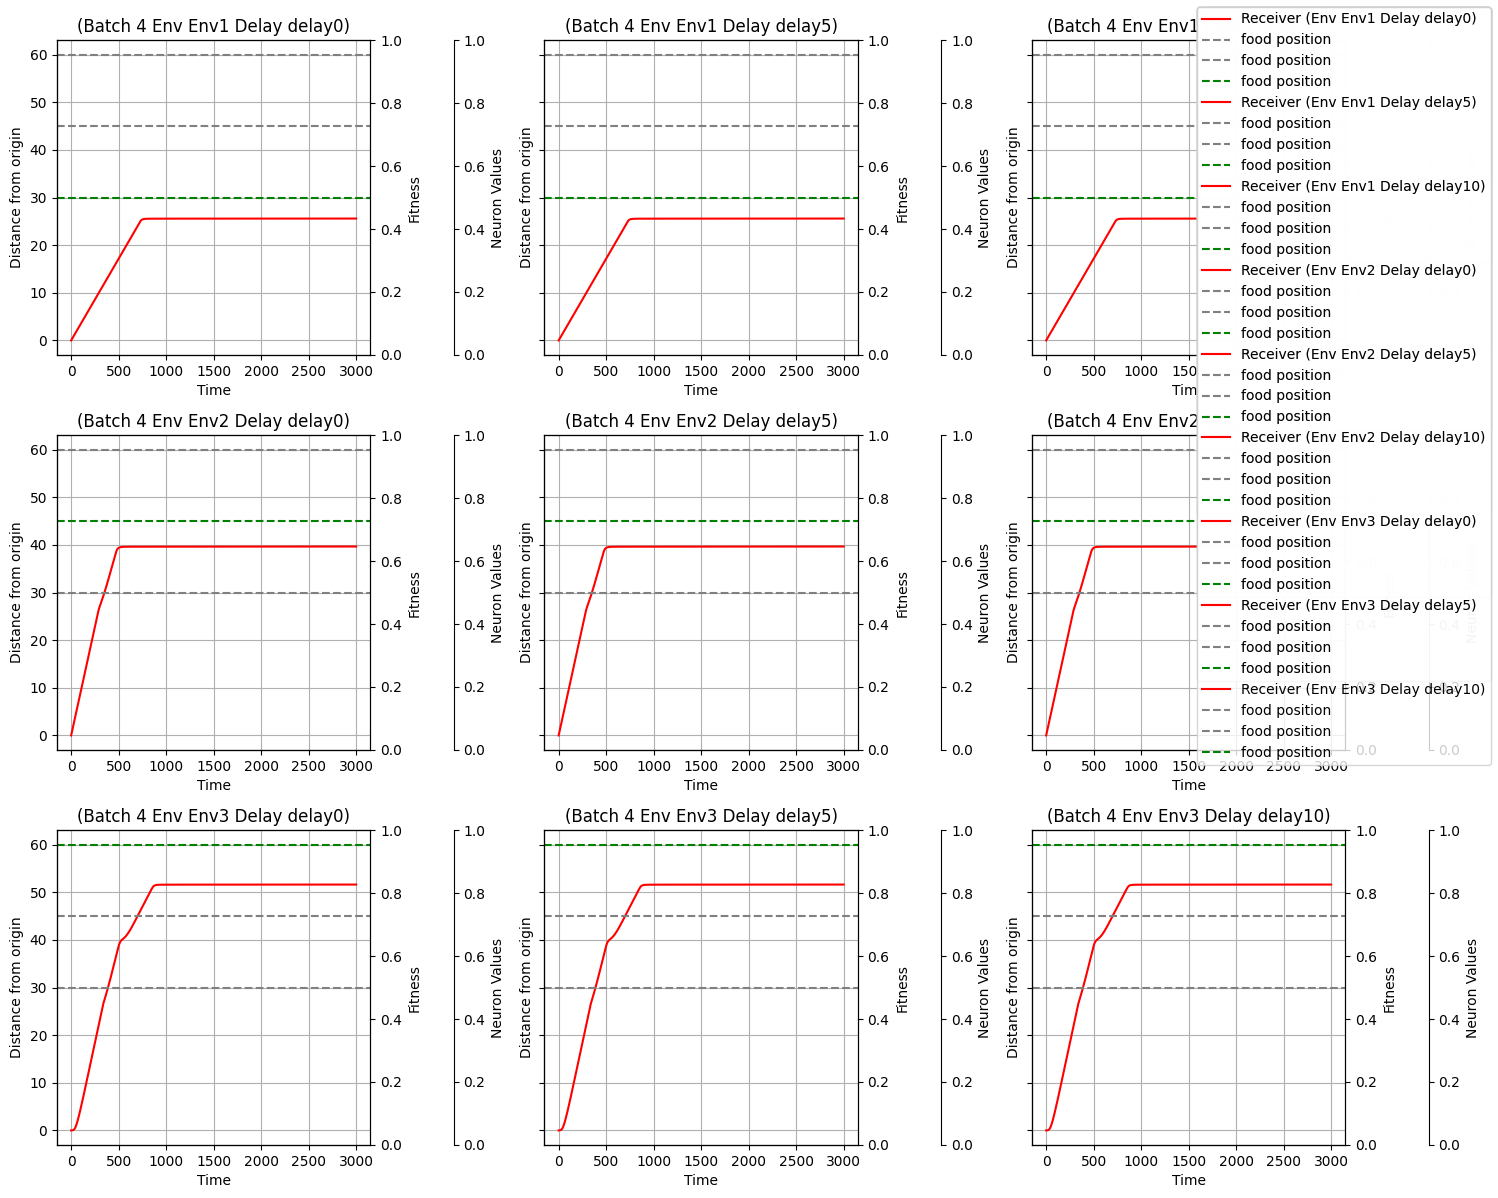

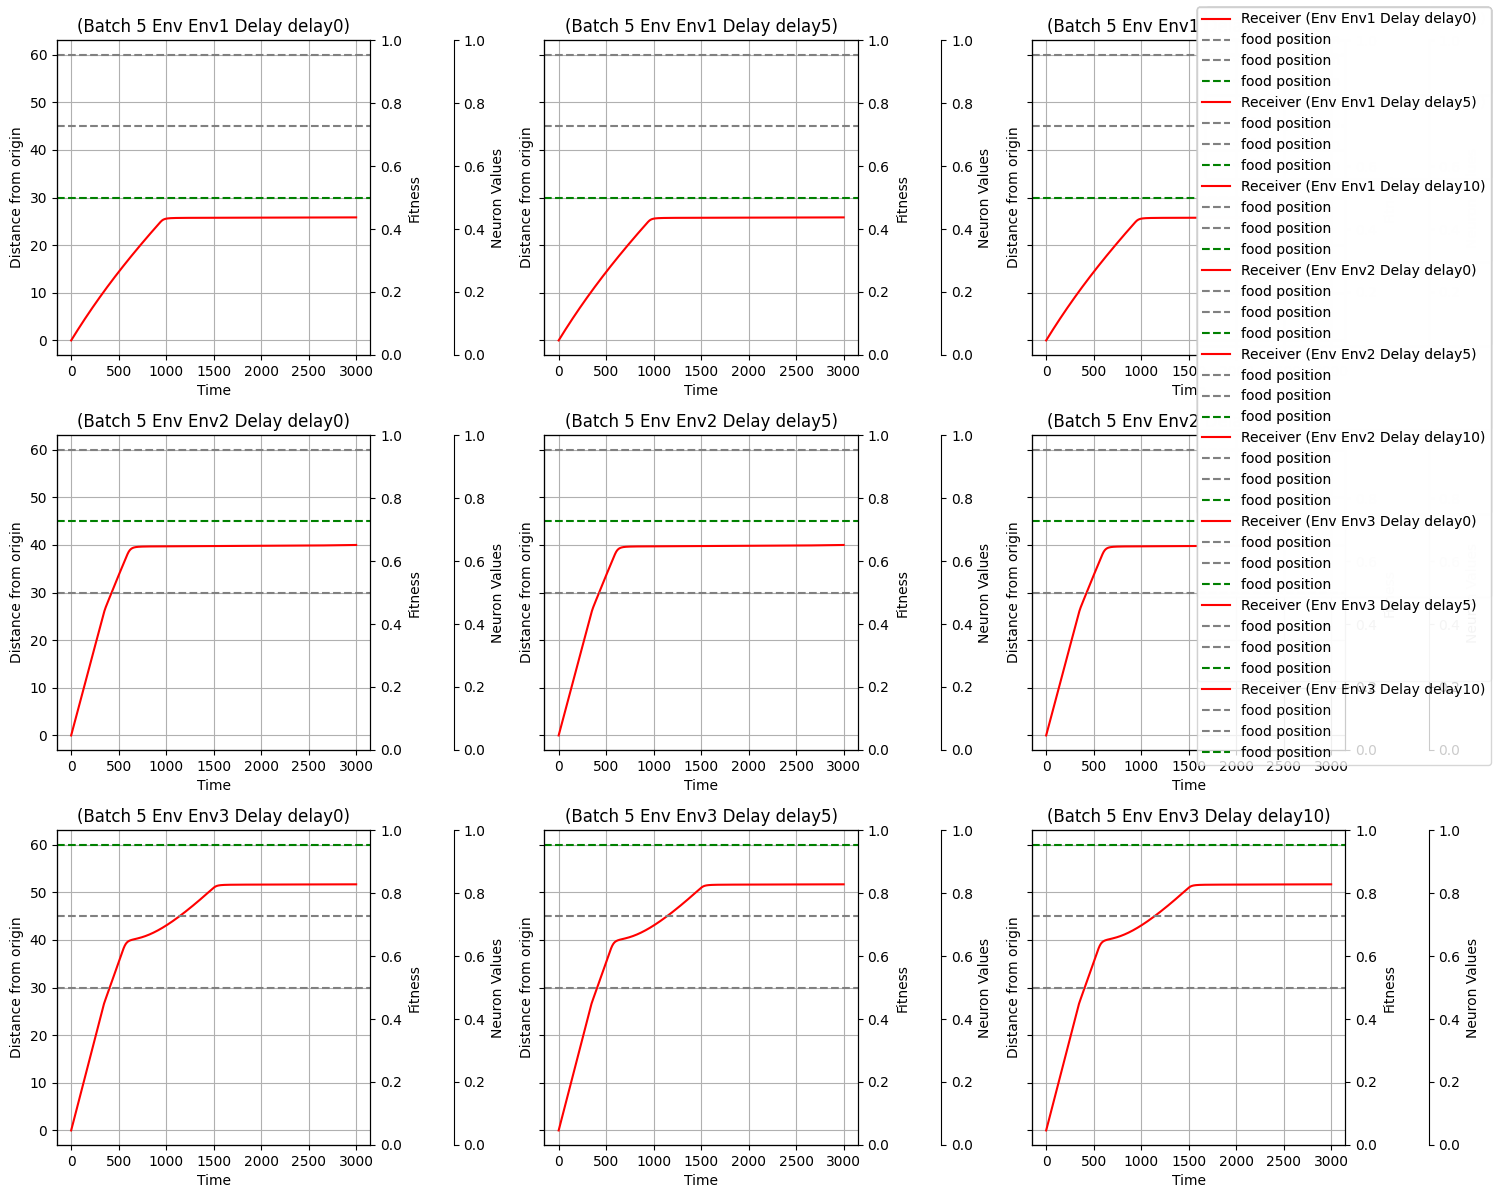

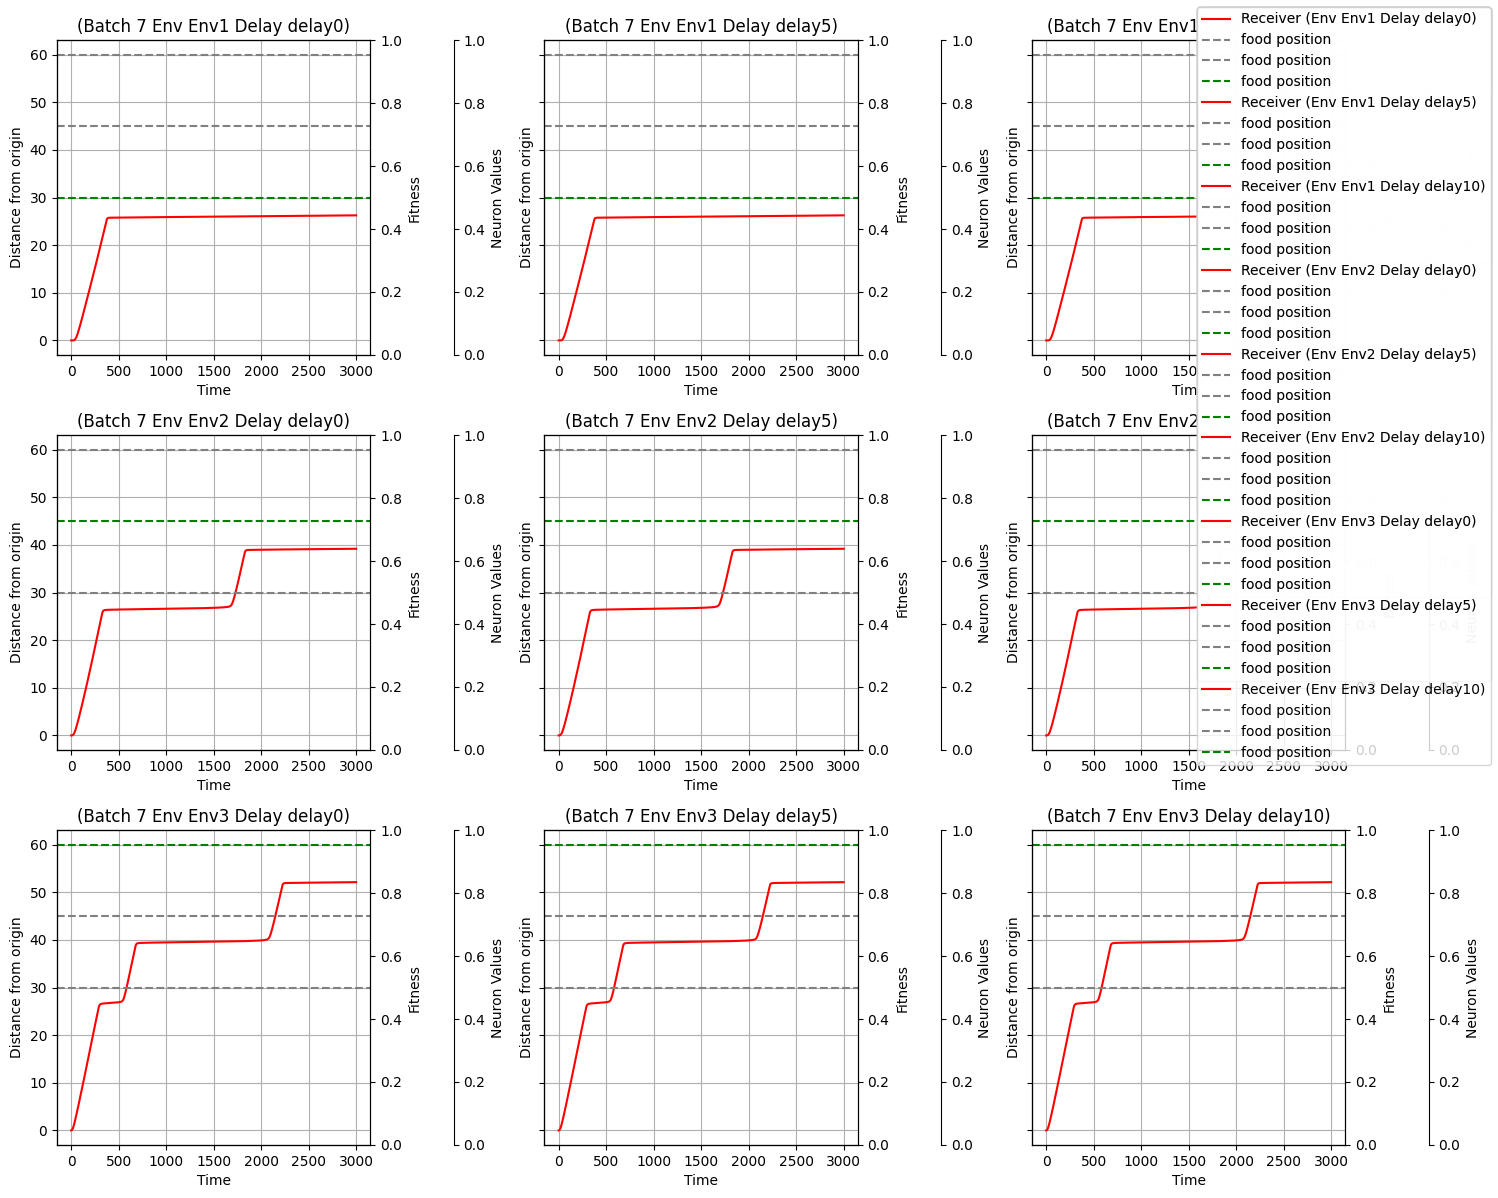

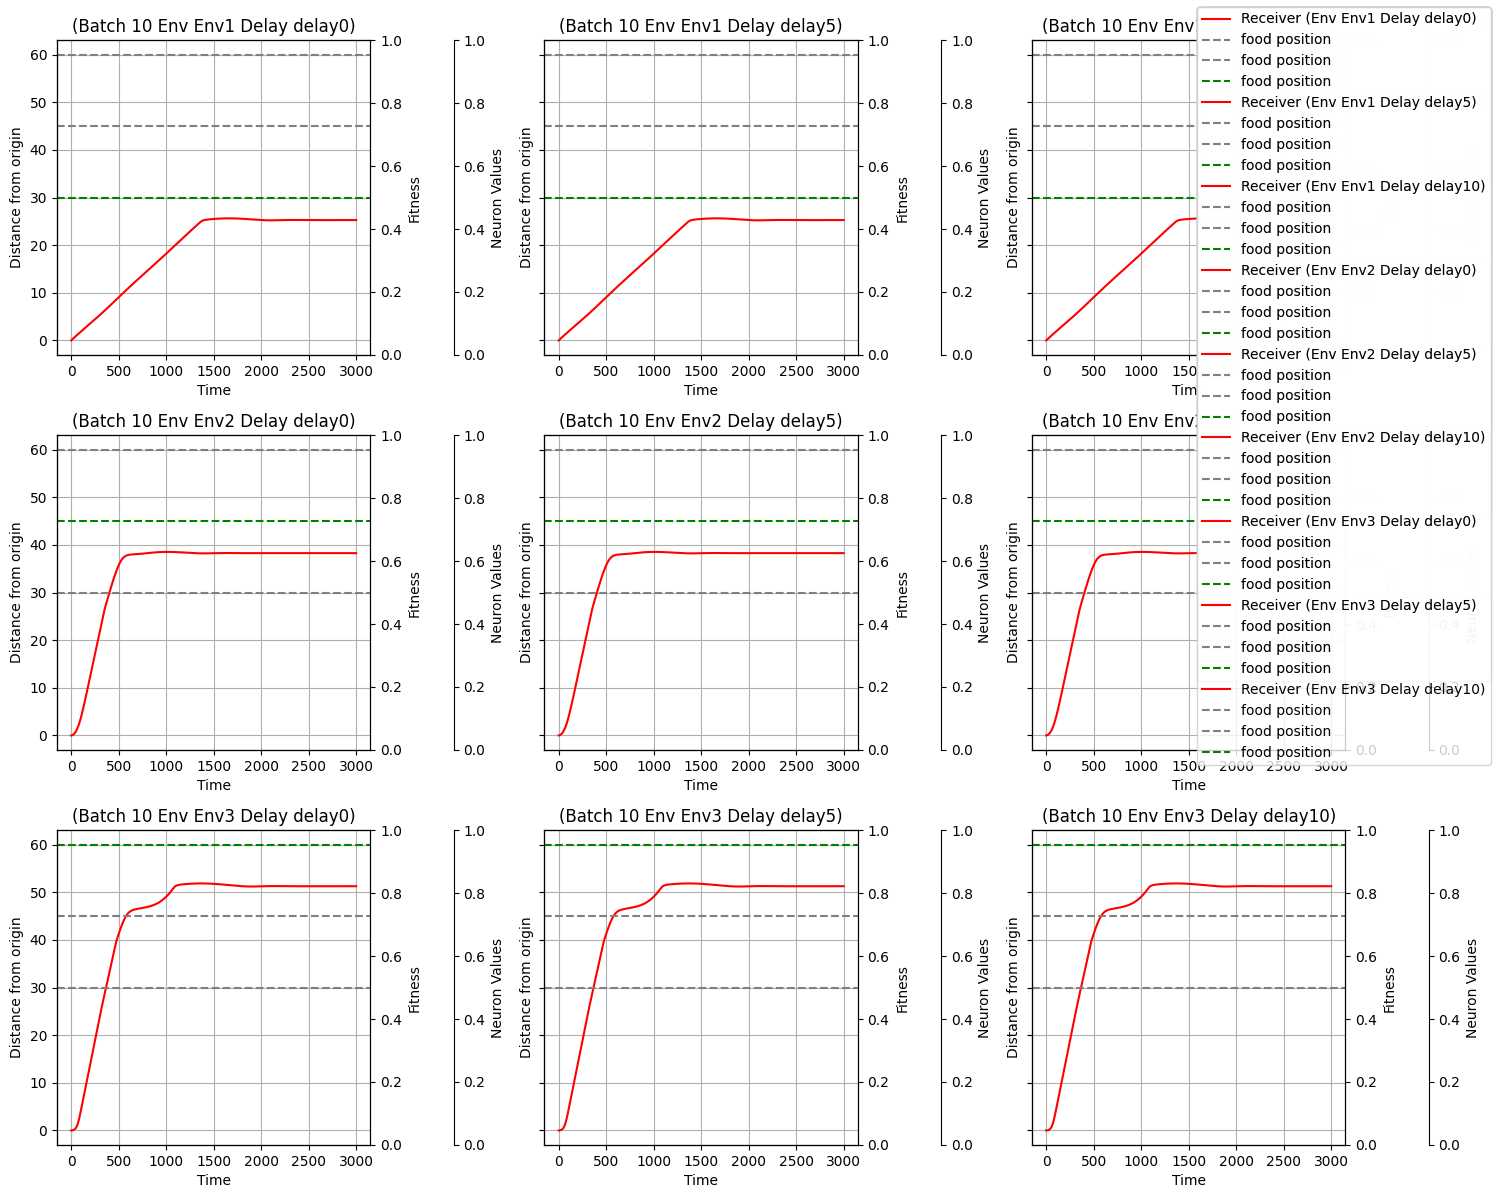

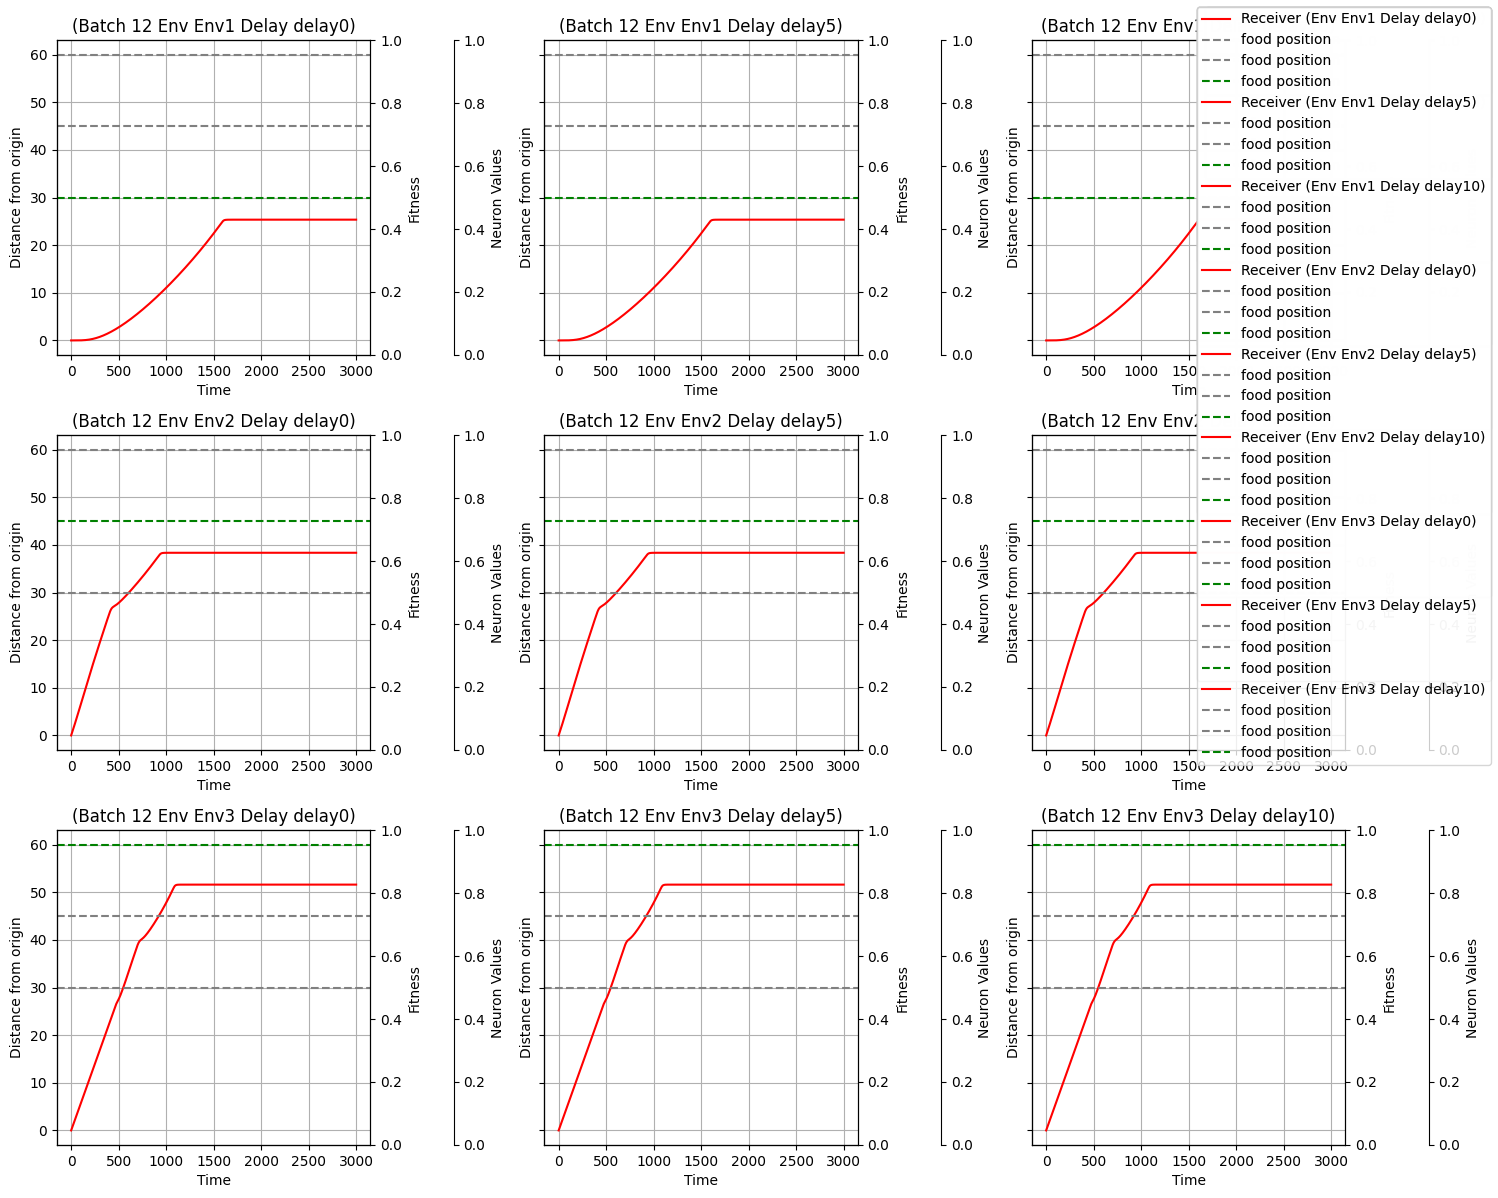

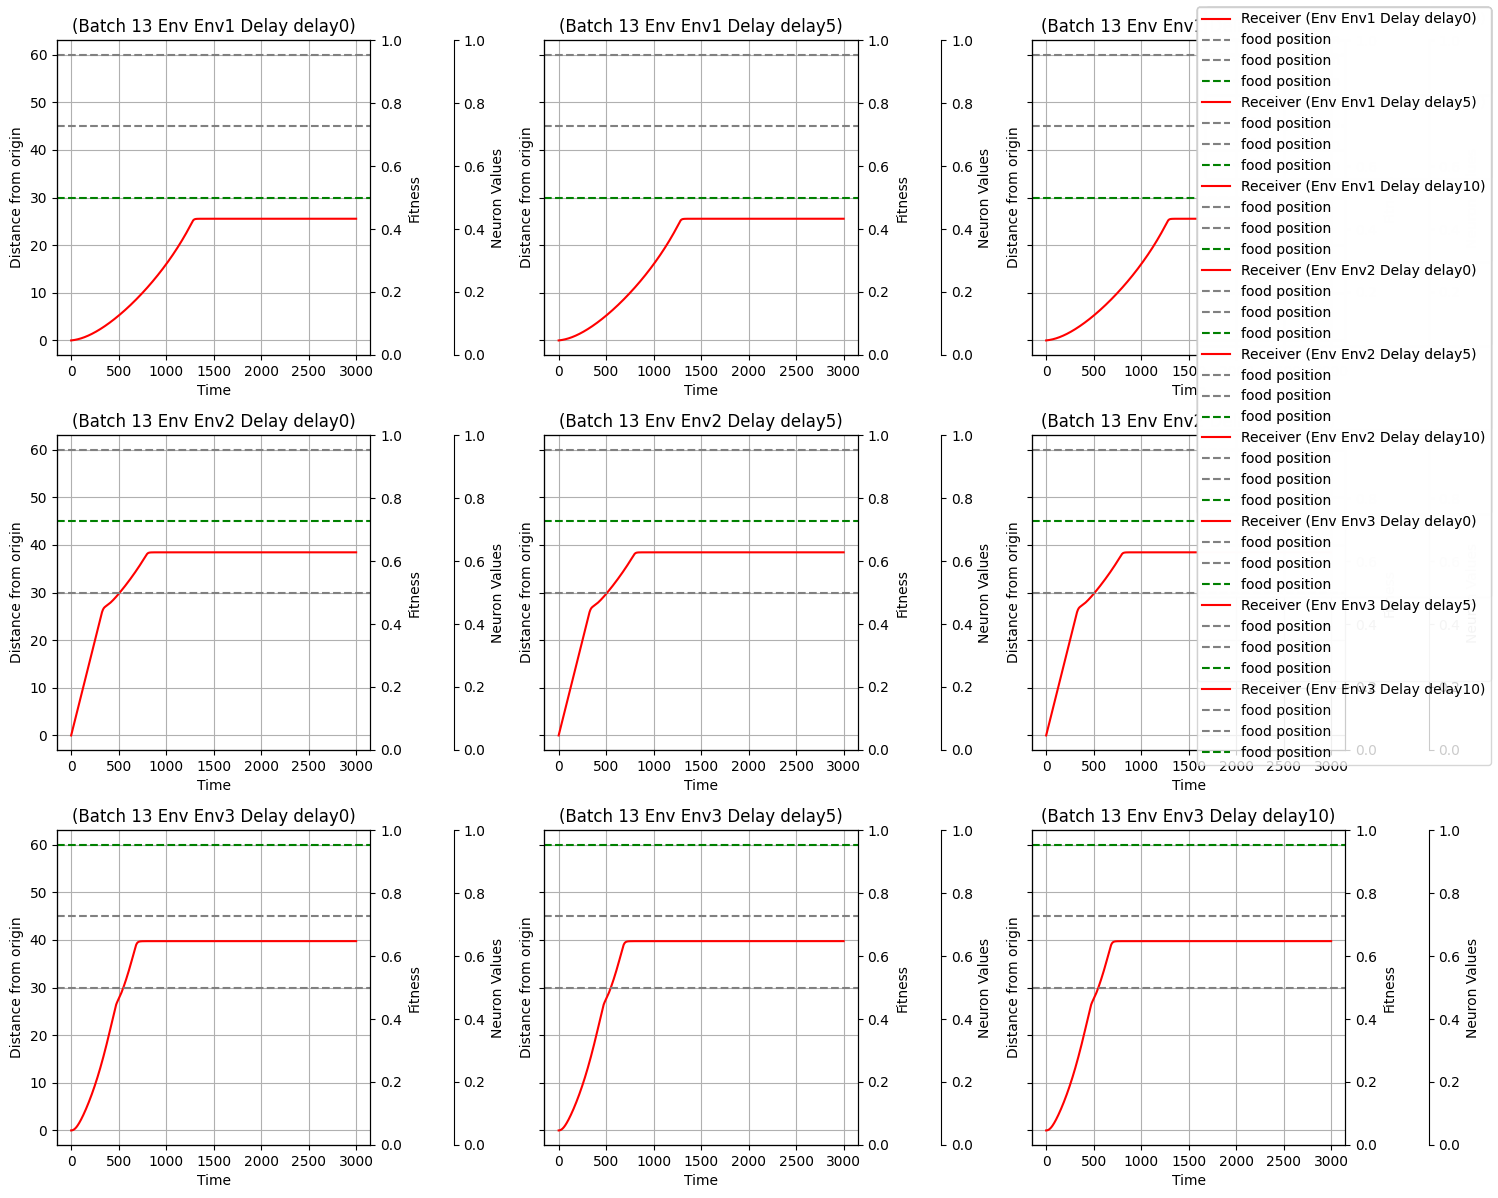

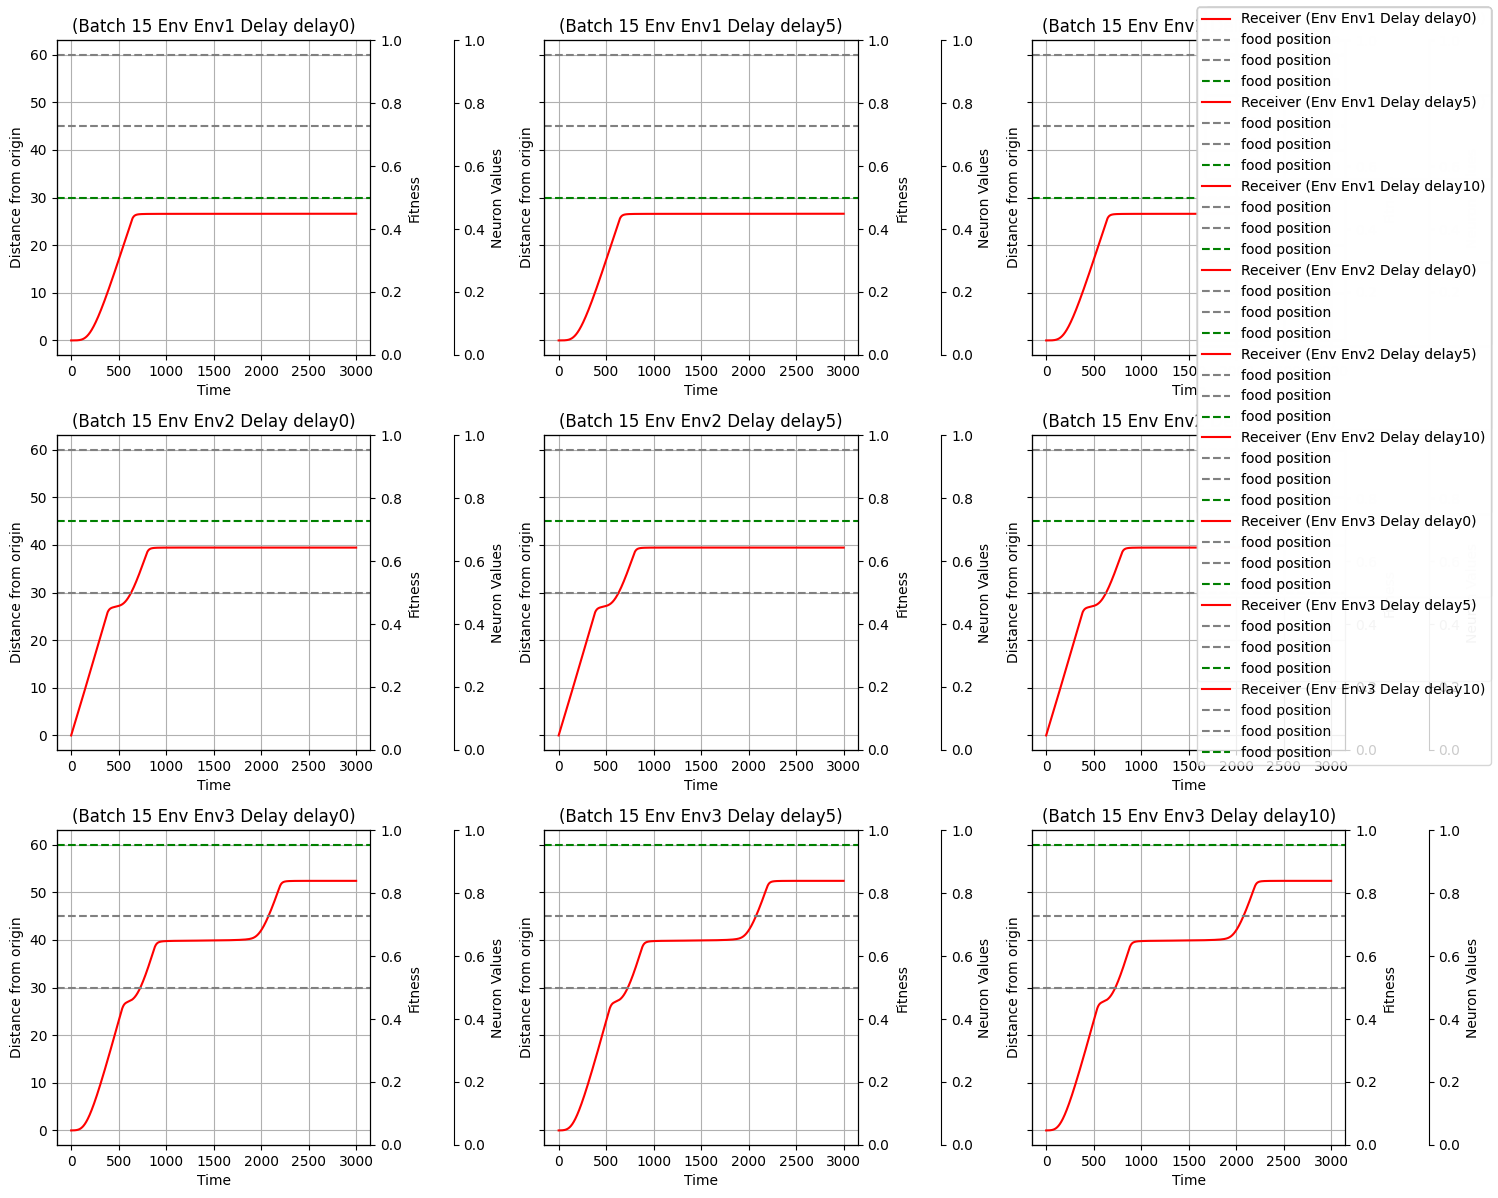

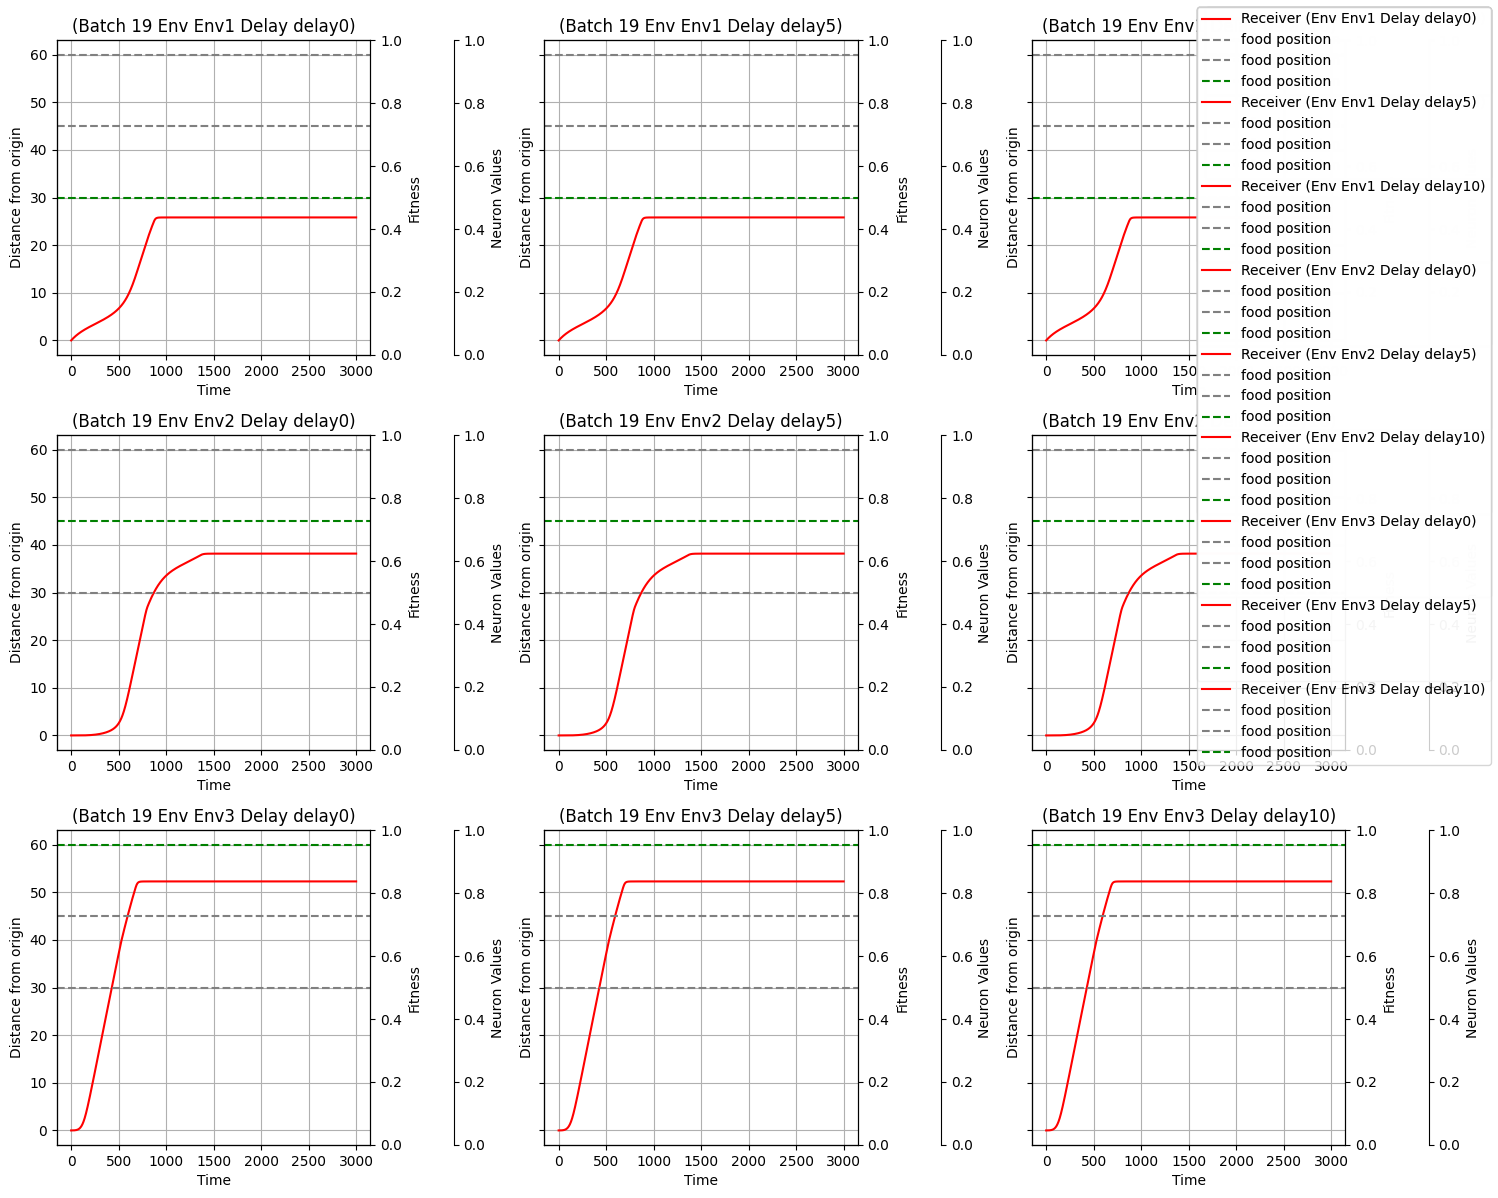

In [ ]:
# training phase + pause behaviour
# this is looking at a single file
# phases = ["Phase1", "Phase2"]
phases = ["Phase3"]

delays = ["delay0", "delay5", "delay10"]
envs = ["Env1", "Env2", "Env3"]

run = 0

# batches = [0,1,2,3,4,5,6,7,8,9,11,12,13,14,15,16,17,18,19]
batches = [1,2,3,4,5,7,10,12,13,15,19]

# batches = [0,1,2,3,4,5,8,11,12,13,14]
for batch_index, batch in enumerate(batches):
    fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):
        for delay_index, delay in enumerate(delays):

            ax = axes[env_index, delay_index]

            # fig, ax = plt.subplots(figsize=(16,10))
            ax2 = ax.twinx()
            ax3 = ax.twinx()          # Third y-axis

            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))

            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)
  
            combined = []

            offset = 0
            for stage in phases:
                # get the agents movements
                phase_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env}_{delay}_{stage}.dat"
                agent = read_ith_line(1, phase_dir)

                # ax.axvline(offset, linestyle="--", label=f"{stage}", color="grey")
                # combined_signaller.extend(signaller)
                combined.extend(agent)

                # offset += stage_length


            # # make the fitness plot
            # fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
            # fitness = read_ith_line(trial*env, fitness_file)
            # stage_length = len(combined)
            # fitness_length = len(fitness)
            # fitness_start = offset + (stage_length - fitness_length)
            # fitness_end = offset + stage_length
            # fitness_x = range(fitness_start, fitness_end)

            # ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")



            x = list(range(0, len(combined)))

            # plot the signaller and receiver
            ax.plot(x, combined, label=f"Receiver (Env {env} Delay {delay})", color="red")

            landmark_file2 = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_{env}_{delay}_phase2.dat"
            landmark = read_ith_line(1, landmark_file2)

            # plot the line marking the landmark position

            food = landmark[3]
            landmarks = [0,1,2]
            for i in landmarks:
                if (landmark[i] != food):
                    ax.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


            ax.axhline(y=food, linestyle="--", label="food position", color="green")


            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            # ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            ax3.set_ylabel("Neuron Values")

            ax.set_title(f"(Batch {batch} Env {env} Delay {delay})")
            ax.grid(True)
            
            fig.tight_layout()
            # fig.legend()
            fig.show()

In [ ]:
# this is looking at a single file
phases = ["Phase1", "Phase2", "Phase3"]
delays = ["delay0", "delay5", "delay10"]
envs = ["Env1", "Env2", "Env3"]

run = 0

# batches = [0,1,2,3,4,5,6,7,8,9,11,12,13,14,15,16,17,18,19]
batches = [1,2,3,4,5,7,10,12,13,15,19]

# batches = [0,1,2,3,4,5,8,11,12,13,14]
for batch_index, batch in enumerate(batches):
    fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):
        for delay_index, delay in enumerate(delays):

            ax = axes[env_index, delay_index]

            # fig, ax = plt.subplots(figsize=(16,10))
            ax2 = ax.twinx()
            ax3 = ax.twinx()          # Third y-axis

            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))

            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)
  
            combined = []

            offset = 0
            for stage in phases:
                # get the agents movements
                phase_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env}_{delay}_{stage}.dat"
                agent = read_ith_line(0, phase_dir)


                ax.axvline(offset, linestyle="--", label=f"{stage}", color="grey")

                

                
                

                # combined_signaller.extend(signaller)
                combined.extend(receiver)

                offset += stage_length


            # make the fitness plot
            fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
            fitness = read_ith_line(trial*env, fitness_file)
            stage_length = len(combined)
            fitness_length = len(fitness)
            fitness_start = offset + (stage_length - fitness_length)
            fitness_end = offset + stage_length
            fitness_x = range(fitness_start, fitness_end)

            ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")



            x = list(range(0, len(combined)))

            # plot the signaller and receiver
            ax.plot(x, combined, label=f"Receiver (Env {env} Trial {trial})", color="red")
            # ax.plot(x, combined_signaller, label=f"Signaller (Env {env} Trial {trial})", color="blue")
            # ax.plot(x, distance, label="Distance", linestyle=":", color="black")

            landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage1_{run}.dat"
            landmark = read_ith_line(trial*env, landmark_file)

            # plot the line marking the landmark position

            food = landmark[3]
            landmarks = [0,1,2]
            for i in landmarks:
                if (landmark[i] != food):
                    ax.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


            ax.axhline(y=food, linestyle="--", label="food position", color="green")



            # get the neural states
            neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/neuron1_stage1_0.dat"
            neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/neuron2_stage1_0.dat"
            neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/neuron3_stage1_0.dat"
            
            neuron1 = read_ith_line(trial*env, neural_state_1_file)
            neuron2 = read_ith_line(trial*env, neural_state_2_file)
            neuron3 = read_ith_line(trial*env, neural_state_3_file)

            motor = []

            for p in range(len(neuron1)):
                motor.append(neuron2[p]-neuron1[p])


            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            ax3.set_ylabel("Neuron Values")

            ax.set_title(f"(Batch {batch} Env {env} Trial {trial})")
            ax.grid(True)
            
            fig.tight_layout()
            fig.legend()
            fig.show()